In [0]:
# !pip install torch_geometric 
# %pip install s3fs

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 44.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.0/15.0 MB 184.4 MB/s eta 0:00:00
  Attempting uninstall: fsspec
    Found existing installation: fsspec 2023.5.0
    Not uninstalling fsspec at /databricks/python3/lib/python3.12/site-packages, outside environment /local_disk0/.ephemeral_nfs/envs/pythonEnv-eeb35a66-d683-4ab5-a6c2-3409b9ca08d0
    Can't uninstall 'fsspec'. No files were found to uninstall.
  Attempting uninstall: aiosignal
    Found existing installation: aiosignal 1.2.0
    Not uninstalling aiosignal at /databricks/python3/lib/python3.12/site-packages, outside environment /local_disk0/.ephemeral_nfs/envs/pythonEnv-eeb35a66-d683-4ab5-a6c2-3409b9ca08d0
    Can't uninstall 'aiosignal'. No files were found to uninstall.
  Attempting uninstall: aiohappyeyeballs
    Found existing installation: aiohappyeyeballs 2.4.4
    Not uninstalling aiohappyeyeballs at /databricks/python3/lib/python3.12/site-packag

In [0]:
%restart_python or dbutils.library.restartPython()

In [0]:
import json
import concurrent.futures
import numpy as np
import matplotlib.pyplot as plt
 
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GCNConv
 
import s3fs
import pyarrow.parquet as pq
import pyarrow as pa
from sklearn.metrics import roc_auc_score, average_precision_score
 
print("Imports OK")

/local_disk0/.ephemeral_nfs/envs/pythonEnv-bfba6cda-86ae-4dd9-b689-aae9b4a071d3/lib/python3.12/site-packages/torch/_vmap_internals.py:9: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  from torch.utils._pytree import _broadcast_to_and_flatten, tree_flatten, tree_unflatten


Imports OK


In [0]:
S3_ROOT        = "s3://university-research-s20426/tgnn_dataset_v2"
 
PERIODS        = 6          # look-back window (6 minutes)
BATCH_SIZE     = 4          # small batch — each item is (N_active, F, T)
HIDDEN_DIM     = 32         # GCN + GRU hidden size
EPOCHS         = 20
LR             = 0.001
RT_ANOMALY_PCT = 0.95       # top 5% RT = anomaly
MAX_WORKERS    = 16         # parallel S3 threads
 
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device : {DEVICE}")

Device : cpu


In [0]:
fs = s3fs.S3FileSystem
)
 
 
def read_parquet_dir(directory):
    """Read a partitioned parquet directory file-by-file via s3fs."""
    files = [f for f in fs.ls(directory) if f.endswith(".parquet")]
    if not files:
        return None
    tables = []
    for f in files:
        with fs.open(f, "rb") as fh:
            tables.append(pq.read_table(fh))
    return pa.concat_tables(tables).to_pandas()
 
 
def load_manifest(split):
    files = fs.ls(f"{S3_ROOT}/manifests/{split}")
    part  = [f for f in files if "part-" in f][0]
    with fs.open(part) as fh:
        content = fh.read()
        if isinstance(content, bytes):
            content = content.decode("utf-8")
        parsed = json.loads(content.strip())
        if isinstance(parsed, str):
            parsed = json.loads(parsed)
        return parsed
 
 
def load_stats():
    files = fs.ls(f"{S3_ROOT}/dataset_stats")
    part  = [f for f in files if "part-" in f][0]
    with fs.open(part) as fh:
        content = fh.read()
        if isinstance(content, bytes):
            content = content.decode("utf-8")
        parsed = json.loads(content.strip())
        if isinstance(parsed, str):
            parsed = json.loads(parsed)
        return parsed
 
 
def load_snapshot_raw(t_idx, split):
    """Load raw DataFrames for one snapshot. Returns (nodes_df, edges_df)."""
    node_dir = f"{S3_ROOT}/snapshots/{split}/nodes/t_idx={t_idx}"
    edge_dir = f"{S3_ROOT}/snapshots/{split}/edges/t_idx={t_idx}"
    try:
        nodes_df = read_parquet_dir(node_dir)
        edges_df = read_parquet_dir(edge_dir)
        if nodes_df is None or edges_df is None:
            return None, None
        if nodes_df.empty or edges_df.empty:
            return None, None
        return nodes_df, edges_df
    except Exception as e:
        return None, None
 
 

In [0]:

# 3. Load metadata

print("\nLoading manifests and stats...")
 
train_manifest = load_manifest("train")
val_manifest   = load_manifest("val")
test_manifest  = load_manifest("test")
stats          = load_stats()
 
NODE_FEATURE_NAMES = stats["node_feature_names"]
EDGE_FEATURE_NAMES = [c for c in stats["edge_feature_names"]
                      if c != "rpctype_idx"]
NODE_FEAT_DIM      = len(NODE_FEATURE_NAMES)
EDGE_FEAT_DIM      = len(EDGE_FEATURE_NAMES)
 
print(f"Node feature dim  : {NODE_FEAT_DIM}")
print(f"Edge feature dim  : {EDGE_FEAT_DIM}")
print(f"Train snapshots   : {train_manifest['count']}")
print(f"Val   snapshots   : {val_manifest['count']}")
print(f"Test  snapshots   : {test_manifest['count']}")


Loading manifests and stats...
Node feature dim  : 27
Edge feature dim  : 4
Train snapshots   : 650
Val   snapshots   : 50
Test  snapshots   : 20


In [0]:

# 4. Compute RT anomaly threshold  (from training data only)

print("\nComputing RT anomaly threshold...")
 
rt_values = []
sample_t  = train_manifest["t_indices"][::10][:30]  # 30 snapshots is enough
 
for t in sample_t:
    _, edges_df = load_snapshot_raw(t, "train")
    if edges_df is not None and "rt_log_mean_rs" in edges_df.columns:
        rt_values.extend(edges_df["rt_log_mean_rs"].dropna().tolist())
 
assert len(rt_values) > 0, "No RT values found — check snapshot loading"
 
RT_THRESHOLD = float(np.percentile(rt_values, RT_ANOMALY_PCT * 100))
print(f"RT threshold (p{int(RT_ANOMALY_PCT*100)}) : {RT_THRESHOLD:.4f}")
print(f"Collected from {len(rt_values):,} edge observations")


Computing RT anomaly threshold...
RT threshold (p95) : 5.8384
Collected from 167,363 edge observations


In [0]:

# 5. Snapshot → tensors
#    Only keeps nodes/edges ACTIVE in this snapshot (not all NUM_NODES)
#    This keeps memory manageable

 
def snapshot_to_tensors(t_idx, split):
    """
    Convert one snapshot to tensors.
 
    Returns dict:
        x          : (N, NODE_FEAT_DIM)
        edge_index : (2, E)
        edge_attr  : (E, EDGE_FEAT_DIM)
        y_edge     : (E,)   binary anomaly label
        N          : int    number of active nodes
        E          : int    number of edges
    or None if snapshot is missing/empty.
    """
    nodes_df, edges_df = load_snapshot_raw(t_idx, split)
    if nodes_df is None:
        return None
 
    # Node features (active nodes only)
    feat_cols = [c for c in NODE_FEATURE_NAMES if c in nodes_df.columns]
    x = torch.tensor(
        nodes_df[feat_cols].fillna(0).values.astype(np.float32),
        dtype=torch.float,
    )   # (N, NODE_FEAT_DIM)
 
    N = len(nodes_df)
 
    # Local node index: global node_id -> 0..N-1
    local_map = {
        int(row["node_id"]): i
        for i, (_, row) in enumerate(nodes_df.iterrows())
    }
 
    
    src_g = edges_df["src_node_id"].fillna(-1).astype(int).values
    dst_g = edges_df["dst_node_id"].fillna(-1).astype(int).values
 
    # Keep only edges where both endpoints are in this snapshot
    mask      = np.array([s in local_map and d in local_map
                           for s, d in zip(src_g, dst_g)])
    edges_df  = edges_df[mask].reset_index(drop=True)
    src_local = np.array([local_map[s] for s in src_g[mask]])
    dst_local = np.array([local_map[d] for d in dst_g[mask]])
 
    edge_index = torch.tensor(
        np.stack([src_local, dst_local], axis=0), dtype=torch.long
    )   # (2, E)
 
    
    ef_cols   = [c for c in EDGE_FEATURE_NAMES if c in edges_df.columns]
    edge_attr = torch.tensor(
        edges_df[ef_cols].fillna(0).values.astype(np.float32),
        dtype=torch.float,
    )   # (E, EDGE_FEAT_DIM)
 
    
    if "rt_log_mean_rs" in edges_df.columns:
        y_edge = torch.tensor(
            (edges_df["rt_log_mean_rs"].fillna(0).values
             > RT_THRESHOLD).astype(np.float32)
        )
    else:
        y_edge = torch.zeros(len(edges_df), dtype=torch.float)
 
    return {
        "x":          x,
        "edge_index": edge_index,
        "edge_attr":  edge_attr,
        "y_edge":     y_edge,
        "N":          N,
        "E":          len(edges_df),
    }
 
# Quick test
print("\nTesting snapshot loader...")
test_snap = snapshot_to_tensors(train_manifest["t_indices"][0], "train")
assert test_snap is not None, "Snapshot loading failed"
print(f"  x          : {test_snap['x'].shape}")
print(f"  edge_index : {test_snap['edge_index'].shape}")
print(f"  edge_attr  : {test_snap['edge_attr'].shape}")
print(f"  y_edge     : {test_snap['y_edge'].shape}")
print(f"  anomaly %  : {test_snap['y_edge'].mean():.3f}")
print("Snapshot loader OK")


Testing snapshot loader...
  x          : torch.Size([1303, 27])
  edge_index : torch.Size([2, 895])
  edge_attr  : torch.Size([895, 4])
  y_edge     : torch.Size([895])
  anomaly %  : 0.121
Snapshot loader OK


In [0]:

# 6. Dataset  — parallel loading + sliding windows

 
class TGCNDataset(torch.utils.data.Dataset):
    """
    Loads all snapshots in parallel, then builds sliding windows.
    Each item = window of PERIODS consecutive snapshots.
    """
 
    def __init__(self, manifest, split, periods=PERIODS,
                 max_workers=MAX_WORKERS):
        self.periods = periods
        self.split   = split
        t_list       = manifest["t_indices"]
 
        # Parallel snapshot loading 
        print(f"\n[{split}] Loading {len(t_list)} snapshots "
              f"(parallel, workers={max_workers})...")
 
        cache = {}
 
        def _load(t):
            return t, snapshot_to_tensors(t, split)
 
        with concurrent.futures.ThreadPoolExecutor(
            max_workers=max_workers
        ) as ex:
            futures = {ex.submit(_load, t): t for t in t_list}
            done    = 0
            for fut in concurrent.futures.as_completed(futures):
                t, s = fut.result()
                if s is not None:
                    cache[t] = s
                done += 1
                if done % 100 == 0:
                    print(f"  {done}/{len(t_list)} loaded", end="\r")
 
        print(f"  {len(cache)}/{len(t_list)} snapshots loaded OK")
        self._cache = cache
 
        # Build valid consecutive windows
        valid_t      = sorted(cache.keys())
        self.windows = []
 
        for i in range(len(valid_t) - periods):
            window = valid_t[i: i + periods]
            # Check all PERIODS snapshots are consecutive
            if window[-1] - window[0] == periods - 1:
                self.windows.append(window)
 
        print(f"  {len(self.windows)} sliding windows "
              f"(PERIODS={periods})")
 
    def __len__(self):
        return len(self.windows)
 
    def __getitem__(self, idx):
        window = self.windows[idx]
 
        # Node features stacked over time: list of (N, F) -> (N, F, T)
        frames = [self._cache[t]["x"] for t in window]
 
        # All frames must have same N — use the last snapshot's N as reference
        # Pad smaller frames with zeros if needed
        N_ref = frames[-1].size(0)
        padded = []
        for f in frames:
            N_i = f.size(0)
            if N_i < N_ref:
                pad = torch.zeros(N_ref - N_i, NODE_FEAT_DIM)
                f   = torch.cat([f, pad], dim=0)
            elif N_i > N_ref:
                f = f[:N_ref]
            padded.append(f)
 
        X    = torch.stack(padded, dim=-1)   # (N_ref, F, T)
        last = self._cache[window[-1]]
 
        return X, last["edge_index"], last["edge_attr"], last["y_edge"]
 
 
# Collate: pad edges to same size within a batch 
def collate_fn(batch):
    """
    Node tensors: pad to max_N in batch.
    Edge tensors: pad to max_E in batch.
    """
    max_N  = max(b[0].size(0) for b in batch)
    max_E  = max(b[1].size(1) for b in batch)
    f_dim  = batch[0][0].size(1)   # renamed: lowercase, no conflict with F
    t_dim  = batch[0][0].size(2)

    X_list, EI_list, EA_list, Y_list = [], [], [], []

    for X, EI, EA, Y in batch:
        N = X.size(0)
        E = EI.size(1)

        # Pad nodes if needed
        if N < max_N:
            X = torch.cat([
                X,
                torch.zeros(max_N - N, f_dim, t_dim)
            ], dim=0)

        # Pad edges
        pad_E = max_E - E
        EI    = torch.nn.functional.pad(EI, (0, pad_E),       value=0)
        EA    = torch.nn.functional.pad(EA, (0, 0, 0, pad_E), value=0.0)
        Y     = torch.nn.functional.pad(Y,  (0, pad_E),       value=0.0)

        X_list.append(X)
        EI_list.append(EI)
        EA_list.append(EA)
        Y_list.append(Y)

    return (
        torch.stack(X_list,  dim=0),   # (B, max_N, f_dim, t_dim)
        torch.stack(EI_list, dim=0),   # (B, 2, max_E)
        torch.stack(EA_list, dim=0),   # (B, max_E, edge_feat_dim)
        torch.stack(Y_list,  dim=0),   # (B, max_E)
    )
 
train_dataset = TGCNDataset(train_manifest, "train")
val_dataset   = TGCNDataset(val_manifest,   "val")
test_dataset  = TGCNDataset(test_manifest,  "test")
# Build datasets
train_loader = torch.utils.data.DataLoader(
    train_dataset, batch_size=BATCH_SIZE,
    shuffle=True,  drop_last=True,  collate_fn=collate_fn,
)
val_loader = torch.utils.data.DataLoader(
    val_dataset,   batch_size=BATCH_SIZE,
    shuffle=False, drop_last=False, collate_fn=collate_fn,
)
test_loader = torch.utils.data.DataLoader(
    test_dataset,  batch_size=BATCH_SIZE,
    shuffle=False, drop_last=False, collate_fn=collate_fn,
)
 
print(f"\nTrain batches : {len(train_loader)}")
print(f"Val   batches : {len(val_loader)}")
print(f"Test  batches : {len(test_loader)}")


[train] Loading 650 snapshots (parallel, workers=16)...
  650/650 snapshots loaded OK
  644 sliding windows (PERIODS=6)

[val] Loading 50 snapshots (parallel, workers=16)...
  50/50 snapshots loaded OK
  44 sliding windows (PERIODS=6)

[test] Loading 20 snapshots (parallel, workers=16)...
  20/20 snapshots loaded OK
  14 sliding windows (PERIODS=6)

Train batches : 161
Val   batches : 11
Test  batches : 4


In [0]:
class TGCNCell(nn.Module):
    """
    One step of TGCN:
      GCN spatial aggregation -> GRU temporal update
    """
    def __init__(self, in_channels, hidden_dim):
        super().__init__()
        self.gcn = GCNConv(in_channels, hidden_dim, add_self_loops=True)
        self.gru = nn.GRUCell(hidden_dim, hidden_dim)
 
    def forward(self, x, edge_index, h):
        """
        x          : (N, in_channels)
        edge_index : (2, E)
        h          : (N, hidden_dim)
        returns h_new : (N, hidden_dim)
        """
        gcn_out = self.gcn(x, edge_index)   # (N, hidden_dim)
        gcn_out = F.relu(gcn_out)
        h_new   = self.gru(gcn_out, h)      # (N, hidden_dim)
        return h_new
 
 
class TGCN(nn.Module):
    """
    Full TGCN model:
      - TGCNCell unrolled over PERIODS time steps
      - Edge anomaly head on final hidden state
    """
    def __init__(self, node_feat_dim, hidden_dim, periods):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.periods    = periods
 
        self.tgcn_cell = TGCNCell(node_feat_dim, hidden_dim)
 
        # Edge anomaly head: concat(src_h, dst_h) -> score
        self.edge_head = nn.Sequential(
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(hidden_dim, 1),
            nn.Sigmoid(),
        )
 
    def forward(self, x, edge_index):
        """
        x          : (B, N, F, T)
        edge_index : (B, 2, E)
 
        Returns scores : (B, E)
        """
        B, N, F, T = x.shape
        device      = x.device
 
        all_scores = []
 
        for b in range(B):
            x_b  = x[b]           # (N, F, T)
            ei_b = edge_index[b]  # (2, E)
 
            # Initial hidden state
            h = torch.zeros(N, self.hidden_dim, device=device)
 
            # Unroll over time steps
            for t in range(T):
                x_t = x_b[:, :, t]             # (N, F)
                h   = self.tgcn_cell(x_t, ei_b, h)
 
            # h is now (N, hidden_dim) — encodes spatiotemporal info
 
            # Edge anomaly score: use src + dst hidden states
            src     = ei_b[0]                  # (E,)
            dst     = ei_b[1]                  # (E,)
            src_h   = h[src]                   # (E, hidden_dim)
            dst_h   = h[dst]                   # (E, hidden_dim)
            edge_h  = torch.cat([src_h, dst_h], dim=-1)  # (E, 2*hidden)
            scores  = self.edge_head(edge_h).squeeze(-1)  # (E,)
 
            all_scores.append(scores)
 
        return torch.stack(all_scores, dim=0)  # (B, E)
 
 
# Instantiate
model     = TGCN(
    node_feat_dim=NODE_FEAT_DIM,
    hidden_dim=HIDDEN_DIM,
    periods=PERIODS,
).to(DEVICE)
 
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
 
print("\nModel:")
print(model)
print(f"\nTotal parameters: {sum(p.numel() for p in model.parameters()):,}")
 


Model:
TGCN(
  (tgcn_cell): TGCNCell(
    (gcn): GCNConv(27, 32)
    (gru): GRUCell(32, 32)
  )
  (edge_head): Sequential(
    (0): Linear(in_features=64, out_features=32, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.1, inplace=False)
    (3): Linear(in_features=32, out_features=1, bias=True)
    (4): Sigmoid()
  )
)

Total parameters: 9,345


In [0]:

# 8. Loss — Focal Loss for imbalanced anomaly detection

def focal_loss(pred, target, gamma=2.0, alpha=0.25):
    """
    pred, target : (B, E) — values in [0, 1]
    Downweights easy negatives so model focuses on rare anomalies.
    """
    bce = F.binary_cross_entropy(pred, target, reduction="none")
    pt  = torch.where(target == 1, pred, 1 - pred)
    w   = torch.where(
        target == 1,
        torch.full_like(pred, alpha),
        torch.full_like(pred, 1 - alpha),
    )
    return (w * (1 - pt) ** gamma * bce).mean()

In [0]:

# 9. Training Loop

train_loss_history = []
val_auroc_history  = []
best_val_auroc     = 0.0
 
print("\nStarting training...")
 
for epoch in range(EPOCHS):
 
    #  Train 
    model.train()
    loss_list = []
 
    for step, (X_b, EI_b, EA_b, Y_b) in enumerate(train_loader):
        X_b  = X_b.to(DEVICE)    # (B, N, F, T)
        EI_b = EI_b.to(DEVICE)   # (B, 2, E)
        Y_b  = Y_b.to(DEVICE)    # (B, E)
 
        y_hat = model(X_b, EI_b)             # (B, E)
        loss  = focal_loss(y_hat, Y_b)
 
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
 
        loss_list.append(loss.item())
 
        if (step + 1) % 20 == 0:
            print(
                f"  Epoch {epoch+1:2d}  "
                f"step {step+1:4d}/{len(train_loader)}  "
                f"loss={np.mean(loss_list):.4f}",
                end="\r"
            )
 
    epoch_loss = float(np.mean(loss_list))
    train_loss_history.append(epoch_loss)
 
    #  Validation 
    model.eval()
    all_preds, all_targets = [], []
 
    with torch.no_grad():
        for X_b, EI_b, EA_b, Y_b in val_loader:
            X_b  = X_b.to(DEVICE)
            EI_b = EI_b.to(DEVICE)
 
            y_hat = model(X_b, EI_b)
            all_preds.append(y_hat.cpu().numpy().flatten())
            all_targets.append(Y_b.numpy().flatten())
 
    all_preds   = np.concatenate(all_preds)
    all_targets = np.concatenate(all_targets)
 
    if all_targets.sum() > 0:
        val_auroc = roc_auc_score(all_targets, all_preds)
        val_auprc = average_precision_score(all_targets, all_preds)
    else:
        val_auroc = val_auprc = 0.0
 
    val_auroc_history.append(val_auroc)
 
    print(
        f"Epoch {epoch+1:2d}/{EPOCHS}  "
        f"loss={epoch_loss:.4f}  "
        f"val_AUROC={val_auroc:.4f}  "
        f"val_AUPRC={val_auprc:.4f}  "
        f"pos%={all_targets.mean()*100:.1f}"
    )
 
    if val_auroc > best_val_auroc:
        best_val_auroc = val_auroc
        torch.save(model.state_dict(), "best_tgcn.pt")
        print(f"  -> Best model saved (AUROC={val_auroc:.4f})")
 
print(f"\nTraining done. Best val AUROC: {best_val_auroc:.4f}")
 


Starting training...
Epoch  1/20  loss=0.0351  val_AUROC=0.6405  val_AUPRC=0.2002  pos%=11.9
  -> Best model saved (AUROC=0.6405)
Epoch  2/20  loss=0.0275  val_AUROC=0.6885  val_AUPRC=0.2434  pos%=11.9
  -> Best model saved (AUROC=0.6885)
Epoch  3/20  loss=0.0261  val_AUROC=0.7180  val_AUPRC=0.2624  pos%=11.9
  -> Best model saved (AUROC=0.7180)
Epoch  4/20  loss=0.0254  val_AUROC=0.7308  val_AUPRC=0.2821  pos%=11.9
  -> Best model saved (AUROC=0.7308)
Epoch  5/20  loss=0.0245  val_AUROC=0.7336  val_AUPRC=0.2441  pos%=11.9
  -> Best model saved (AUROC=0.7336)
Epoch  6/20  loss=0.0238  val_AUROC=0.7585  val_AUPRC=0.3044  pos%=11.9
  -> Best model saved (AUROC=0.7585)
Epoch  7/20  loss=0.0230  val_AUROC=0.7825  val_AUPRC=0.3810  pos%=11.9
  -> Best model saved (AUROC=0.7825)
Epoch  8/20  loss=0.0220  val_AUROC=0.7943  val_AUPRC=0.4207  pos%=11.9
  -> Best model saved (AUROC=0.7943)
Epoch  9/20  loss=0.0214  val_AUROC=0.8047  val_AUPRC=0.4479  pos%=11.9
  -> Best model saved (AUROC=0.804

In [0]:

# 10. Test Evaluation

 
model.load_state_dict(torch.load("best_tgcn.pt", map_location=DEVICE))
model.eval()
 
all_preds, all_targets = [], []
 
with torch.no_grad():
    for X_b, EI_b, EA_b, Y_b in test_loader:
        X_b  = X_b.to(DEVICE)
        EI_b = EI_b.to(DEVICE)
 
        y_hat = model(X_b, EI_b)
        all_preds.append(y_hat.cpu().numpy().flatten())
        all_targets.append(Y_b.numpy().flatten())
 
all_preds   = np.concatenate(all_preds)
all_targets = np.concatenate(all_targets)
 
test_auroc = roc_auc_score(all_targets, all_preds)
test_auprc = average_precision_score(all_targets, all_preds)
 
print("\n=== TEST RESULTS ===")
print(f"AUROC    : {test_auroc:.4f}")
print(f"AUPRC    : {test_auprc:.4f}")
print(f"Anomaly% : {all_targets.mean()*100:.2f}%")
print(f"Samples  : {len(all_targets):,}")
 


=== TEST RESULTS ===
AUROC    : 0.8630
AUPRC    : 0.6090
Anomaly% : 11.64%
Samples  : 12,356


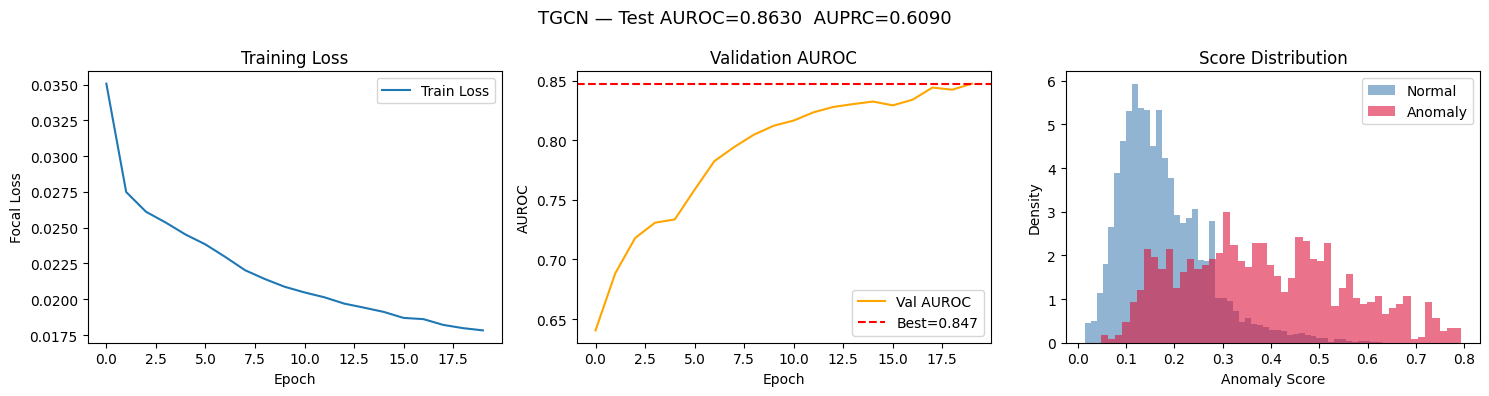

Saved: tgcn_results.png


In [0]:

# 11. Plots

 
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
 
# Loss curve
axes[0].plot(train_loss_history, label="Train Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Focal Loss")
axes[0].set_title("Training Loss")
axes[0].legend()
 
# AUROC curve
axes[1].plot(val_auroc_history, label="Val AUROC", color="orange")
axes[1].axhline(best_val_auroc, linestyle="--", color="red",
                label=f"Best={best_val_auroc:.3f}")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("AUROC")
axes[1].set_title("Validation AUROC")
axes[1].legend()
 
# Score distribution
normal_scores  = all_preds[all_targets == 0]
anomaly_scores = all_preds[all_targets == 1]
axes[2].hist(normal_scores,  bins=50, alpha=0.6,
             color="steelblue", label="Normal",  density=True)
axes[2].hist(anomaly_scores, bins=50, alpha=0.6,
             color="crimson",   label="Anomaly", density=True)
axes[2].set_xlabel("Anomaly Score")
axes[2].set_ylabel("Density")
axes[2].set_title("Score Distribution")
axes[2].legend()
 
plt.suptitle(
    f"TGCN — Test AUROC={test_auroc:.4f}  AUPRC={test_auprc:.4f}",
    fontsize=13
)
plt.tight_layout()
plt.savefig("tgcn_results.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: tgcn_results.png")

# Spatial-Temporal Graph Attention Network

In [0]:
import json
import concurrent.futures
import numpy as np
import matplotlib.pyplot as plt
 
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GATv2Conv
 
import s3fs
import pyarrow.parquet as pq
import pyarrow as pa
from sklearn.metrics import roc_auc_score, average_precision_score
 
print("Imports OK")

Imports OK


In [0]:
S3_ROOT        = "s3://university-research-s20426/tgnn_dataset_v2"
 
PERIODS            = 6           # look-back window  (6 minutes)
BATCH_SIZE         = 4
HIDDEN_DIM         = 64          # was 32 — doubled for GAT heads
GAT_HEADS          = 4           # attention heads in GATv2Conv
TRANSFORMER_LAYERS = 2           # depth of temporal encoder
TRANSFORMER_HEADS  = 4           # attention heads in Transformer
EPOCHS             = 20
LR                 = 1e-3
WEIGHT_DECAY       = 1e-4        # AdamW regularisation
GRAD_CLIP          = 1.0         # max gradient norm
RT_ANOMALY_PCT     = 0.95
MAX_WORKERS        = 16
 
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device : {DEVICE}")

Device : cpu


###  Helper Function

In [0]:
def read_parquet_dir(directory):
    """Read a partitioned parquet directory file-by-file via s3fs."""
    files = [f for f in fs.ls(directory) if f.endswith(".parquet")]
    if not files:
        return None
    tables = []
    for f in files:
        with fs.open(f, "rb") as fh:
            tables.append(pq.read_table(fh))
    return pa.concat_tables(tables).to_pandas()
 
 
def load_manifest(split):
    files = fs.ls(f"{S3_ROOT}/manifests/{split}")
    part  = [f for f in files if "part-" in f][0]
    with fs.open(part) as fh:
        content = fh.read()
        if isinstance(content, bytes):
            content = content.decode("utf-8")
        parsed = json.loads(content.strip())
        if isinstance(parsed, str):
            parsed = json.loads(parsed)
        return parsed
 
 
def load_stats():
    files = fs.ls(f"{S3_ROOT}/dataset_stats")
    part  = [f for f in files if "part-" in f][0]
    with fs.open(part) as fh:
        content = fh.read()
        if isinstance(content, bytes):
            content = content.decode("utf-8")
        parsed = json.loads(content.strip())
        if isinstance(parsed, str):
            parsed = json.loads(parsed)
        return parsed
 
 
def load_snapshot_raw(t_idx, split):
    node_dir = f"{S3_ROOT}/snapshots/{split}/nodes/t_idx={t_idx}"
    edge_dir = f"{S3_ROOT}/snapshots/{split}/edges/t_idx={t_idx}"
    try:
        nodes_df = read_parquet_dir(node_dir)
        edges_df = read_parquet_dir(edge_dir)
        if nodes_df is None or edges_df is None:
            return None, None
        if nodes_df.empty or edges_df.empty:
            return None, None
        return nodes_df, edges_df
    except Exception:
        return None, None

### Load metadata

In [0]:
print("\nLoading manifests and stats...")
 
train_manifest = load_manifest("train")
val_manifest   = load_manifest("val")
test_manifest  = load_manifest("test")
stats          = load_stats()
 
NODE_FEATURE_NAMES = stats["node_feature_names"]
EDGE_FEATURE_NAMES = [c for c in stats["edge_feature_names"]
                      if c != "rpctype_idx"]
NODE_FEAT_DIM      = len(NODE_FEATURE_NAMES)
EDGE_FEAT_DIM      = len(EDGE_FEATURE_NAMES)
 
print(f"Node feature dim  : {NODE_FEAT_DIM}")
print(f"Edge feature dim  : {EDGE_FEAT_DIM}")
print(f"Train snapshots   : {train_manifest['count']}")
print(f"Val   snapshots   : {val_manifest['count']}")
print(f"Test  snapshots   : {test_manifest['count']}")

### Compute RT anomaly threshold

In [0]:
# rt_values = []
# sample_t  = train_manifest["t_indices"][::10][:30]
 
# for t in sample_t:
#     _, edges_df = load_snapshot_raw(t, "train")
#     if edges_df is not None and "rt_log_mean_rs" in edges_df.columns:
#         rt_values.extend(edges_df["rt_log_mean_rs"].dropna().tolist())
 
# assert len(rt_values) > 0, "No RT values found — check snapshot loading"
 
# RT_THRESHOLD = float(np.percentile(rt_values, RT_ANOMALY_PCT * 100))
# print(f"RT threshold (p{int(RT_ANOMALY_PCT * 100)}) : {RT_THRESHOLD:.4f}")
# print(f"Collected from {len(rt_values):,} edge observations")

### Snapshot to tensors

In [0]:
def snapshot_to_tensors(t_idx, split):
    """
    Convert one snapshot to tensors.
 
    Returns dict with:
        x          : (N, NODE_FEAT_DIM)
        edge_index : (2, E)
        edge_attr  : (E, EDGE_FEAT_DIM)   ← same as before; model NOW uses this
        y_edge     : (E,)
        N          : int
        E          : int
    """
    nodes_df, edges_df = load_snapshot_raw(t_idx, split)
    if nodes_df is None:
        return None
 
    feat_cols = [c for c in NODE_FEATURE_NAMES if c in nodes_df.columns]
    x = torch.tensor(
        nodes_df[feat_cols].fillna(0).values.astype(np.float32),
        dtype=torch.float,
    )
 
    N = len(nodes_df)
 
    local_map = {
        int(row["node_id"]): i
        for i, (_, row) in enumerate(nodes_df.iterrows())
    }
 
    src_g = edges_df["src_node_id"].fillna(-1).astype(int).values
    dst_g = edges_df["dst_node_id"].fillna(-1).astype(int).values
 
    mask      = np.array([s in local_map and d in local_map
                          for s, d in zip(src_g, dst_g)])
    edges_df  = edges_df[mask].reset_index(drop=True)
    src_local = np.array([local_map[s] for s in src_g[mask]])
    dst_local = np.array([local_map[d] for d in dst_g[mask]])
 
    edge_index = torch.tensor(
        np.stack([src_local, dst_local], axis=0), dtype=torch.long
    )
 
    ef_cols   = [c for c in EDGE_FEATURE_NAMES if c in edges_df.columns]
    edge_attr = torch.tensor(
        edges_df[ef_cols].fillna(0).values.astype(np.float32),
        dtype=torch.float,
    )
 
    if "rt_log_mean_rs" in edges_df.columns:
        y_edge = torch.tensor(
            (edges_df["rt_log_mean_rs"].fillna(0).values
             > RT_THRESHOLD).astype(np.float32)
        )
    else:
        y_edge = torch.zeros(len(edges_df), dtype=torch.float)
 
    return {
        "x":          x,
        "edge_index": edge_index,
        "edge_attr":  edge_attr,
        "y_edge":     y_edge,
        "N":          N,
        "E":          len(edges_df),
    }
 
 
print("\nTesting snapshot loader...")
test_snap = snapshot_to_tensors(train_manifest["t_indices"][0], "train")
assert test_snap is not None, "Snapshot loading failed"
print(f"  x          : {test_snap['x'].shape}")
print(f"  edge_index : {test_snap['edge_index'].shape}")
print(f"  edge_attr  : {test_snap['edge_attr'].shape}")
print(f"  y_edge     : {test_snap['y_edge'].shape}")
print(f"  anomaly %  : {test_snap['y_edge'].mean():.3f}")
print("Snapshot loader OK")


Testing snapshot loader...
  x          : torch.Size([1303, 27])
  edge_index : torch.Size([2, 895])
  edge_attr  : torch.Size([895, 4])
  y_edge     : torch.Size([895])
  anomaly %  : 0.121
Snapshot loader OK


In [0]:
class TGCNDataset(torch.utils.data.Dataset):
    """
    Loads all snapshots in parallel, then builds sliding windows.
    Each item = PERIODS consecutive snapshots.
    edge_attr and edge_index come from the LAST snapshot in the window.
    """
 
    def __init__(self, manifest, split, periods=PERIODS,
                 max_workers=MAX_WORKERS):
        self.periods = periods
        t_list       = manifest["t_indices"]
 
        print(f"\n[{split}] Loading {len(t_list)} snapshots "
              f"(parallel, workers={max_workers})...")
 
        cache = {}
 
        def _load(t):
            return t, snapshot_to_tensors(t, split)
 
        with concurrent.futures.ThreadPoolExecutor(
            max_workers=max_workers
        ) as ex:
            futures = {ex.submit(_load, t): t for t in t_list}
            done    = 0
            for fut in concurrent.futures.as_completed(futures):
                t, s = fut.result()
                if s is not None:
                    cache[t] = s
                done += 1
                if done % 100 == 0:
                    print(f"  {done}/{len(t_list)} loaded", end="\r")
 
        print(f"  {len(cache)}/{len(t_list)} snapshots loaded OK")
        self._cache = cache
 
        valid_t      = sorted(cache.keys())
        self.windows = []
        for i in range(len(valid_t) - periods):
            window = valid_t[i: i + periods]
            if window[-1] - window[0] == periods - 1:
                self.windows.append(window)
 
        print(f"  {len(self.windows)} sliding windows (PERIODS={periods})")
 
    def __len__(self):
        return len(self.windows)
 
    def __getitem__(self, idx):
        window = self.windows[idx]
        frames = [self._cache[t]["x"] for t in window]
 
        N_ref  = frames[-1].size(0)
        padded = []
        for f in frames:
            N_i = f.size(0)
            if N_i < N_ref:
                pad = torch.zeros(N_ref - N_i, NODE_FEAT_DIM)
                f   = torch.cat([f, pad], dim=0)
            elif N_i > N_ref:
                f = f[:N_ref]
            padded.append(f)
 
        X    = torch.stack(padded, dim=-1)   # (N_ref, F, T)
        last = self._cache[window[-1]]
 
        return X, last["edge_index"], last["edge_attr"], last["y_edge"]
    
def collate_fn(batch):
    """Pad nodes and edges to max sizes in the batch."""
    max_N = max(b[0].size(0) for b in batch)
    max_E = max(b[1].size(1) for b in batch)
    f_dim = batch[0][0].size(1)
    t_dim = batch[0][0].size(2)
 
    X_list, EI_list, EA_list, Y_list = [], [], [], []
 
    for X, EI, EA, Y in batch:
        N = X.size(0)
        E = EI.size(1)
 
        if N < max_N:
            X = torch.cat([
                X, torch.zeros(max_N - N, f_dim, t_dim)
            ], dim=0)
 
        pad_E = max_E - E
        EI    = F.pad(EI, (0, pad_E),       value=0)
        EA    = F.pad(EA, (0, 0, 0, pad_E), value=0.0)
        Y     = F.pad(Y,  (0, pad_E),       value=0.0)
 
        X_list.append(X)
        EI_list.append(EI)
        EA_list.append(EA)
        Y_list.append(Y)
 
    return (
        torch.stack(X_list,  dim=0),   # (B, max_N, F, T)
        torch.stack(EI_list, dim=0),   # (B, 2, max_E)
        torch.stack(EA_list, dim=0),   # (B, max_E, EDGE_FEAT_DIM)
        torch.stack(Y_list,  dim=0),   # (B, max_E)
    )
 
 
train_dataset = TGCNDataset(train_manifest, "train")
val_dataset   = TGCNDataset(val_manifest,   "val")
test_dataset  = TGCNDataset(test_manifest,  "test")
 
train_loader = torch.utils.data.DataLoader(
    train_dataset, batch_size=BATCH_SIZE,
    shuffle=True,  drop_last=True,  collate_fn=collate_fn,
)
val_loader = torch.utils.data.DataLoader(
    val_dataset,   batch_size=BATCH_SIZE,
    shuffle=False, drop_last=False, collate_fn=collate_fn,
)
test_loader = torch.utils.data.DataLoader(
    test_dataset,  batch_size=BATCH_SIZE,
    shuffle=False, drop_last=False, collate_fn=collate_fn,
)
 
print(f"\nTrain batches : {len(train_loader)}")
print(f"Val   batches : {len(val_loader)}")
print(f"Test  batches : {len(test_loader)}")


[train] Loading 650 snapshots (parallel, workers=16)...
  650/650 snapshots loaded OK
  644 sliding windows (PERIODS=6)

[val] Loading 50 snapshots (parallel, workers=16)...
  50/50 snapshots loaded OK
  44 sliding windows (PERIODS=6)

[test] Loading 20 snapshots (parallel, workers=16)...
  20/20 snapshots loaded OK
  14 sliding windows (PERIODS=6)

Train batches : 161
Val   batches : 11
Test  batches : 4


### GATCell-spatial aggregation with attention

In [0]:
class GATCell(nn.Module):
    """
    One spatial step of the ST-GAT.
 
    Input : node features (N, in_channels) + edge_index + edge_attr
    Output: node embeddings (N, hidden_dim)  with attention + LayerNorm
    """
    def __init__(self, in_channels, hidden_dim, edge_dim,
                 heads=GAT_HEADS, dropout=0.1):
        super().__init__()
        assert hidden_dim % heads == 0, \
            f"hidden_dim ({hidden_dim}) must be divisible by heads ({heads})"
 
        # GATv2Conv — each head outputs hidden_dim // heads features
        # concat=True  →  final output = hidden_dim  (heads × hidden_dim//heads)
        # edge_dim     →  edge_attr is projected and added to attention logits
        self.gat = GATv2Conv(
            in_channels  = in_channels,
            out_channels = hidden_dim // heads,
            heads        = heads,
            concat       = True,
            edge_dim     = edge_dim,
            add_self_loops = True,
            dropout      = dropout,
        )
        self.norm = nn.LayerNorm(hidden_dim)
 
    def forward(self, x, edge_index, edge_attr):
        """
        x          : (N, in_channels)
        edge_index : (2, E)
        edge_attr  : (E, edge_dim)
        returns    : (N, hidden_dim)
        """
        out = self.gat(x, edge_index, edge_attr)   # (N, hidden_dim)
        return self.norm(F.elu(out))               # ELU suits GAT better than ReLU
 

### TemporalTransformerEncoder

In [0]:
class TemporalTransformerEncoder(nn.Module):
    """
    Encodes a sequence of node states over the look-back window.
 
    Input : (N, T, hidden_dim)
    Output: (N, hidden_dim)   — summary using the final attended state
    """
    def __init__(self, hidden_dim, periods,
                 nhead=TRANSFORMER_HEADS,
                 num_layers=TRANSFORMER_LAYERS,
                 dropout=0.1):
        super().__init__()
        # Learnable positional embedding — one vector per time step
        self.pos_enc = nn.Embedding(periods, hidden_dim)
 
        encoder_layer = nn.TransformerEncoderLayer(
            d_model        = hidden_dim,
            nhead          = nhead,
            dim_feedforward = hidden_dim * 4,
            dropout        = dropout,
            batch_first    = True,   # expects (Batch, Seq, Feat)
            norm_first     = True,   # pre-norm for stable gradients
        )
        self.encoder = nn.TransformerEncoder(
            encoder_layer, num_layers=num_layers
        )
        self.norm = nn.LayerNorm(hidden_dim)
 
    def forward(self, x_seq):
        """
        x_seq  : (N, T, hidden_dim)
        returns: (N, hidden_dim)
        """
        T   = x_seq.size(1)
        pos = self.pos_enc(
            torch.arange(T, device=x_seq.device)
        )                                               # (T, H)
        x_seq = x_seq + pos.unsqueeze(0)               # broadcast over N
        out   = self.encoder(x_seq)                    # (N, T, H)
        return self.norm(out[:, -1, :])                # (N, H) — last timestep
 
 
# ── [UPGRADE 3] EdgeAnomalyHead with edge features ────────────
#
#   OLD: MLP(concat(src_h, dst_h))           — 2H input, edge ignored
#   NEW: MLP(concat(src_h, dst_h, edge_h))  — 3H input, full signal
#
#   edge_h = LayerNorm(ReLU(Linear(edge_attr)))
#   This gives the head its own view of the edge's current state
#   (latency, call volume, error rate) independent of node histories.

In [0]:
class EdgeAnomalyHead(nn.Module):
    """
    Scores each edge for anomaly probability in [0, 1].
 
    Score = Sigmoid(MLP(h_src || h_dst || edge_proj(edge_attr)))
    """
    def __init__(self, hidden_dim, edge_feat_dim):
        super().__init__()
        # Project edge features into the same embedding space as nodes
        self.edge_proj = nn.Sequential(
            nn.Linear(edge_feat_dim, hidden_dim),
            nn.ReLU(),
            nn.LayerNorm(hidden_dim),
        )
        # 3 × hidden_dim because we concat src + dst + edge
        self.mlp = nn.Sequential(
            nn.Linear(hidden_dim * 3, hidden_dim * 2),
            nn.ReLU(),
            nn.Dropout(0.15),
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(hidden_dim, 1),
            nn.Sigmoid(),
        )
 
    def forward(self, h, edge_index, edge_attr):
        """
        h          : (N, hidden_dim)
        edge_index : (2, E)
        edge_attr  : (E, edge_feat_dim)
        returns    : (E,)  anomaly scores
        """
        src_h  = h[edge_index[0]]                          # (E, H)
        dst_h  = h[edge_index[1]]                          # (E, H)
        edge_h = self.edge_proj(edge_attr)                 # (E, H)
        cat    = torch.cat([src_h, dst_h, edge_h], dim=-1) # (E, 3H)
        return self.mlp(cat).squeeze(-1)      

In [0]:
# ── Full model: STGATModel ─────────────────────────────────────
 
class STGATModel(nn.Module):
    """
    Spatial-Temporal Graph Attention Network for edge anomaly detection.
 
    Pipeline (per sample in batch):
      x (N,F,T)  →  node_proj (N,H)
        per timestep t:
          GATCell(x_t, edge_index, edge_attr) → h_t (N,H)
        stack → (N,T,H)
          TemporalTransformerEncoder          → h   (N,H)
        EdgeAnomalyHead(h, edge_index, edge_attr) → scores (E,)
    """
 
    def __init__(self, node_feat_dim, edge_feat_dim, hidden_dim, periods):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.periods    = periods
 
        # Project raw node features into hidden_dim before GAT
        self.node_proj = nn.Sequential(
            nn.Linear(node_feat_dim, hidden_dim),
            nn.ReLU(),
            nn.LayerNorm(hidden_dim),
        )
 
        # [UPGRADE 1] Spatial: attention + edge features
        self.gat_cell = GATCell(
            in_channels = hidden_dim,
            hidden_dim  = hidden_dim,
            edge_dim    = edge_feat_dim,
        )
 
        # [UPGRADE 2] Temporal: Transformer over look-back window
        self.temporal_enc = TemporalTransformerEncoder(
            hidden_dim = hidden_dim,
            periods    = periods,
        )
 
        # [UPGRADE 3] Edge scoring head with edge features
        self.edge_head = EdgeAnomalyHead(
            hidden_dim    = hidden_dim,
            edge_feat_dim = edge_feat_dim,
        )
 
    def forward(self, x, edge_index, edge_attr):
        """
        x          : (B, N, F, T)
        edge_index : (B, 2, E)
        edge_attr  : (B, E, EDGE_FEAT_DIM)
 
        Returns scores : (B, E)  ∈  [0, 1]
        """
        B, N, F, T = x.shape
        all_scores  = []
 
        for b in range(B):
            x_b  = x[b]           # (N, F, T)
            ei_b = edge_index[b]  # (2, E)
            ea_b = edge_attr[b]   # (E, EDGE_FEAT_DIM)
 
            # ── Spatial encoding per timestep ──────────────────
            h_seq = []
            for t in range(T):
                x_t = x_b[:, :, t]            # (N, F)
                x_t = self.node_proj(x_t)     # (N, H)
                h_t = self.gat_cell(x_t, ei_b, ea_b)  # (N, H)
                h_seq.append(h_t)
 
            # (T, N, H) → (N, T, H)
            h_seq = torch.stack(h_seq, dim=0).transpose(0, 1)
 
            # ── Temporal encoding over the window ──────────────
            h = self.temporal_enc(h_seq)       # (N, H)
 
            # ── Edge anomaly scoring ───────────────────────────
            scores = self.edge_head(h, ei_b, ea_b)  # (E,)
            all_scores.append(scores)
 
        return torch.stack(all_scores, dim=0)  # (B, E)
 

In [0]:
model = STGATModel(
    node_feat_dim = NODE_FEAT_DIM,
    edge_feat_dim = EDGE_FEAT_DIM,
    hidden_dim    = HIDDEN_DIM,
    periods       = PERIODS,
).to(DEVICE)
 
# [UPGRADE 4] AdamW with weight decay + cosine LR schedule
optimizer = torch.optim.AdamW(
    model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY
)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=EPOCHS, eta_min=1e-5
)
 
print("\nModel:")
print(model)
total_params = sum(p.numel() for p in model.parameters())
print(f"\nTotal parameters: {total_params:,}")


Model:
STGATModel(
  (node_proj): Sequential(
    (0): Linear(in_features=27, out_features=64, bias=True)
    (1): ReLU()
    (2): LayerNorm((64,), eps=1e-05, elementwise_affine=True, bias=True)
  )
  (gat_cell): GATCell(
    (gat): GATv2Conv(64, 16, heads=4)
    (norm): LayerNorm((64,), eps=1e-05, elementwise_affine=True, bias=True)
  )
  (temporal_enc): TemporalTransformerEncoder(
    (pos_enc): Embedding(6, 64)
    (encoder): TransformerEncoder(
      (layers): ModuleList(
        (0-1): 2 x TransformerEncoderLayer(
          (self_attn): MultiheadAttention(
            (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
          )
          (linear1): Linear(in_features=64, out_features=256, bias=True)
          (dropout): Dropout(p=0.1, inplace=False)
          (linear2): Linear(in_features=256, out_features=64, bias=True)
          (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True, bias=True)
          (norm2): LayerNorm((64,), eps

/home/spark-bfba6cda-86ae-4dd9-b689-aa/.ipykernel/7454/command-5412768847718326-140111044:24: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(


In [0]:
def focal_loss(pred, target, gamma=2.0, alpha=0.25):
    """
    pred, target : (B, E)  values in [0, 1]
    Downweights easy negatives; focuses training on rare anomalies.
    """
    bce = F.binary_cross_entropy(pred, target, reduction="none")
    pt  = torch.where(target == 1, pred, 1 - pred)
    w   = torch.where(
        target == 1,
        torch.full_like(pred, alpha),
        torch.full_like(pred, 1 - alpha),
    )
    return (w * (1 - pt) ** gamma * bce).mean()
 
# COMMAND ----------
# ── Training Loop ─────────────────────────────────────────────
 
train_loss_history = []
val_auroc_history  = []
best_val_auroc     = 0.0
 
print("\nStarting training...")
 
for epoch in range(EPOCHS):
 
    # ── Train ──────────────────────────────────────────────────
    model.train()
    loss_list = []
 
    for step, (X_b, EI_b, EA_b, Y_b) in enumerate(train_loader):
        X_b  = X_b.to(DEVICE)    # (B, N, F, T)
        EI_b = EI_b.to(DEVICE)   # (B, 2, E)
        EA_b = EA_b.to(DEVICE)   # (B, E, EDGE_FEAT_DIM)  ← now used by model
        Y_b  = Y_b.to(DEVICE)    # (B, E)
 
        y_hat = model(X_b, EI_b, EA_b)   # (B, E)
        loss  = focal_loss(y_hat, Y_b)
 
        optimizer.zero_grad()
        loss.backward()
        # Gradient clipping prevents exploding gradients in Transformer
        torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
        optimizer.step()
 
        loss_list.append(loss.item())
 
        if (step + 1) % 20 == 0:
            print(
                f"  Epoch {epoch + 1:2d}  "
                f"step {step + 1:4d}/{len(train_loader)}  "
                f"loss={np.mean(loss_list):.4f}",
                end="\r",
            )
 
    scheduler.step()
    epoch_loss = float(np.mean(loss_list))
    train_loss_history.append(epoch_loss)
 
    # ── Validation ─────────────────────────────────────────────
    model.eval()
    all_preds, all_targets = [], []
 
    with torch.no_grad():
        for X_b, EI_b, EA_b, Y_b in val_loader:
            X_b  = X_b.to(DEVICE)
            EI_b = EI_b.to(DEVICE)
            EA_b = EA_b.to(DEVICE)
 
            y_hat = model(X_b, EI_b, EA_b)
            all_preds.append(y_hat.cpu().numpy().flatten())
            all_targets.append(Y_b.numpy().flatten())
 
    all_preds   = np.concatenate(all_preds)
    all_targets = np.concatenate(all_targets)
 
    if all_targets.sum() > 0:
        val_auroc = roc_auc_score(all_targets, all_preds)
        val_auprc = average_precision_score(all_targets, all_preds)
    else:
        val_auroc = val_auprc = 0.0
 
    val_auroc_history.append(val_auroc)
    lr_now = scheduler.get_last_lr()[0]
 
    print(
        f"Epoch {epoch + 1:2d}/{EPOCHS}  "
        f"loss={epoch_loss:.4f}  "
        f"val_AUROC={val_auroc:.4f}  "
        f"val_AUPRC={val_auprc:.4f}  "
        f"pos%={all_targets.mean() * 100:.1f}  "
        f"lr={lr_now:.5f}"
    )
 
    if val_auroc > best_val_auroc:
        best_val_auroc = val_auroc
        torch.save(model.state_dict(), "best_stgat.pt")
        print(f"  -> Best model saved (AUROC={val_auroc:.4f})")
 
print(f"\nTraining done. Best val AUROC: {best_val_auroc:.4f}")


Starting training...
Epoch  1/20  loss=0.0200  val_AUROC=0.9891  val_AUPRC=0.9271  pos%=11.9  lr=0.00099
  -> Best model saved (AUROC=0.9891)
Epoch  2/20  loss=0.0064  val_AUROC=0.9980  val_AUPRC=0.9851  pos%=11.9  lr=0.00098
  -> Best model saved (AUROC=0.9980)
Epoch  3/20  loss=0.0041  val_AUROC=0.9992  val_AUPRC=0.9942  pos%=11.9  lr=0.00095
  -> Best model saved (AUROC=0.9992)
Epoch  4/20  loss=0.0030  val_AUROC=0.9995  val_AUPRC=0.9965  pos%=11.9  lr=0.00091
  -> Best model saved (AUROC=0.9995)
Epoch  5/20  loss=0.0023  val_AUROC=0.9996  val_AUPRC=0.9972  pos%=11.9  lr=0.00086
  -> Best model saved (AUROC=0.9996)
Epoch  6/20  loss=0.0024  val_AUROC=0.9996  val_AUPRC=0.9971  pos%=11.9  lr=0.00080
Epoch  7/20  loss=0.0019  val_AUROC=0.9998  val_AUPRC=0.9982  pos%=11.9  lr=0.00073
  -> Best model saved (AUROC=0.9998)
Epoch  8/20  loss=0.0018  val_AUROC=0.9998  val_AUPRC=0.9985  pos%=11.9  lr=0.00066
  -> Best model saved (AUROC=0.9998)
Epoch  9/20  loss=0.0017  val_AUROC=0.9998  val

In [0]:
model.load_state_dict(torch.load("best_stgat.pt", map_location=DEVICE))
model.eval()
 
all_preds, all_targets = [], []
 
with torch.no_grad():
    for X_b, EI_b, EA_b, Y_b in test_loader:
        X_b  = X_b.to(DEVICE)
        EI_b = EI_b.to(DEVICE)
        EA_b = EA_b.to(DEVICE)
 
        y_hat = model(X_b, EI_b, EA_b)
        all_preds.append(y_hat.cpu().numpy().flatten())
        all_targets.append(Y_b.numpy().flatten())
 
all_preds   = np.concatenate(all_preds)
all_targets = np.concatenate(all_targets)
 
test_auroc = roc_auc_score(all_targets, all_preds)
test_auprc = average_precision_score(all_targets, all_preds)
 
print("\n=== TEST RESULTS ===")
print(f"AUROC    : {test_auroc:.4f}")
print(f"AUPRC    : {test_auprc:.4f}")
print(f"Anomaly% : {all_targets.mean() * 100:.2f}%")
print(f"Samples  : {len(all_targets):,}")


=== TEST RESULTS ===
AUROC    : 0.9999
AUPRC    : 0.9992
Anomaly% : 11.64%
Samples  : 12,356


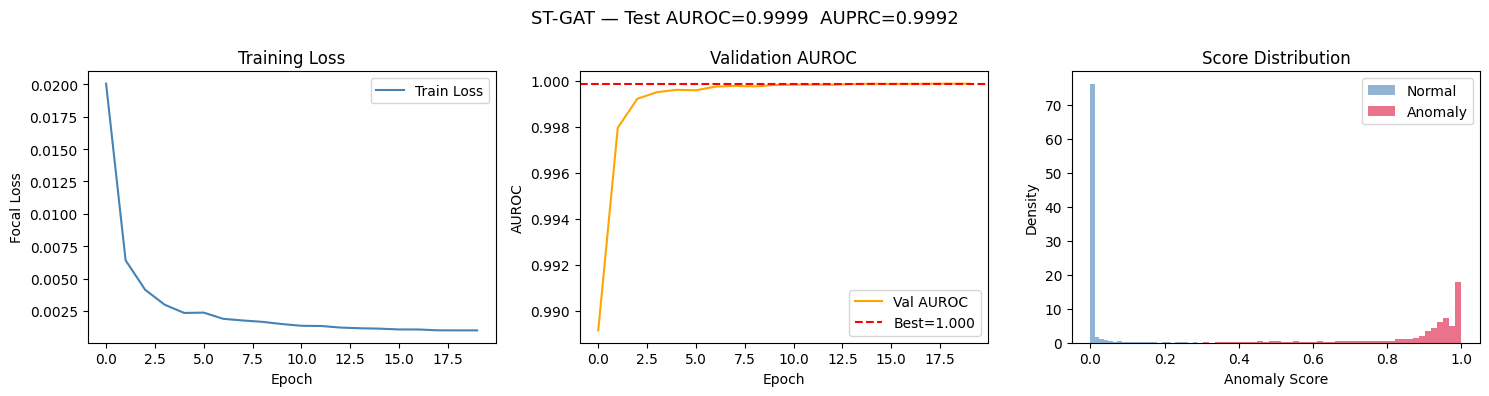

Saved: stgat_results.png


In [0]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
 
# Loss
axes[0].plot(train_loss_history, label="Train Loss", color="steelblue")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Focal Loss")
axes[0].set_title("Training Loss")
axes[0].legend()
 
# AUROC
axes[1].plot(val_auroc_history, label="Val AUROC", color="orange")
axes[1].axhline(best_val_auroc, linestyle="--", color="red",
                label=f"Best={best_val_auroc:.3f}")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("AUROC")
axes[1].set_title("Validation AUROC")
axes[1].legend()
 
# Score distribution
normal_scores  = all_preds[all_targets == 0]
anomaly_scores = all_preds[all_targets == 1]
axes[2].hist(normal_scores,  bins=50, alpha=0.6,
             color="steelblue", label="Normal",  density=True)
axes[2].hist(anomaly_scores, bins=50, alpha=0.6,
             color="crimson",   label="Anomaly", density=True)
axes[2].set_xlabel("Anomaly Score")
axes[2].set_ylabel("Density")
axes[2].set_title("Score Distribution")
axes[2].legend()
 
plt.suptitle(
    f"ST-GAT — Test AUROC={test_auroc:.4f}  AUPRC={test_auprc:.4f}",
    fontsize=13,
)
plt.tight_layout()
plt.savefig("stgat_results.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: stgat_results.png")
 